In [1]:
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [2]:
df = pd.read_csv("../data/processed/final_dataset.csv")

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'http\S+|www\S+', '', text)

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [5]:
df["clean_text"] = df["comment_text"].apply(clean_text)

In [6]:
df[["comment_text", "clean_text", "cyberbullying"]].head(10)

,comment_text,clean_text,cyberbullying
0,Explanation\nWhy the edits made under my usern...,explanation edits made username hardcore metal...,0
1,D'aww! He matches this background colour I'm s...,aww match background colour seemingly stuck th...,0
2,"Hey man, I'm really not trying to edit war. It...",hey man really trying edit war guy constantly ...,0
3,"""\nMore\nI can't make any real suggestions on ...",make real suggestion improvement wondered sect...,0
4,"You, sir, are my hero. Any chance you remember...",sir hero chance remember page,0
5,"""\n\nCongratulations from me as well, use the ...",congratulation well use tool well talk,0
6,COCKSUCKER BEFORE YOU PISS AROUND ON MY WORK,cocksucker piss around work,1
7,Your vandalism to the Matt Shirvington article...,vandalism matt shirvington article reverted pl...,0
8,Sorry if the word 'nonsense' was offensive to ...,sorry word nonsense offensive anyway intending...,0
9,alignment on this subject and which are contra...,alignment subject contrary dulithgow,0


In [7]:
df.to_csv("../data/processed/cleaned_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [9]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_text"])

y = df["cyberbullying"]

print(X.shape)

(159571, 5000)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(127656, 5000)
(31915, 5000)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.9584208052639824


In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     28671
           1       0.92      0.64      0.76      3244

    accuracy                           0.96     31915
   macro avg       0.94      0.82      0.87     31915
weighted avg       0.96      0.96      0.96     31915



In [13]:
sample = ["You are stupid and useless"]

sample_clean = [clean_text(text) for text in sample]

sample_vector = tfidf.transform(sample_clean)

prediction = lr.predict(sample_vector)

if prediction[0] == 1:
    print("Cyberbullying Detected")
else:
    print("Non-Cyberbullying")

Cyberbullying Detected


In [14]:
print(X.shape)

(159571, 5000)


In [15]:
print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.9584208052639824


In [16]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

Naive Bayes Accuracy: 0.9496161679461068


In [17]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9606454645151182


In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9575434748550838


In [19]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "SVM",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        nb_accuracy,
        svm_accuracy,
        rf_accuracy
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.958421
1          Naive Bayes  0.949616
2                  SVM  0.960645
3        Random Forest  0.957543


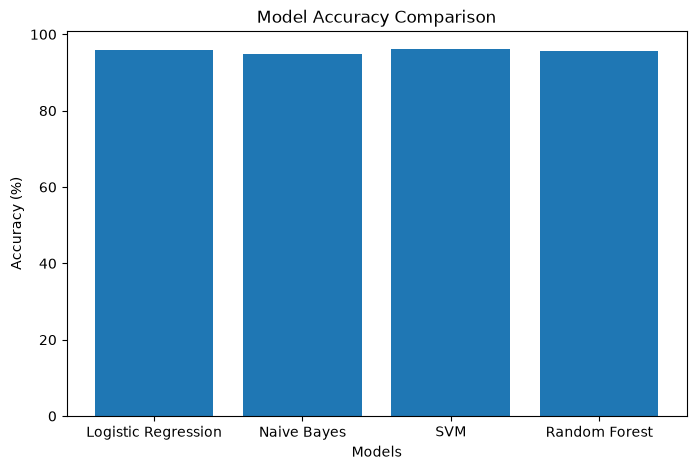

In [20]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Naive Bayes",
    "SVM",
    "Random Forest"
]

accuracies = [
    95.84,
    94.96,
    96.06,
    95.75
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Models")

plt.show()

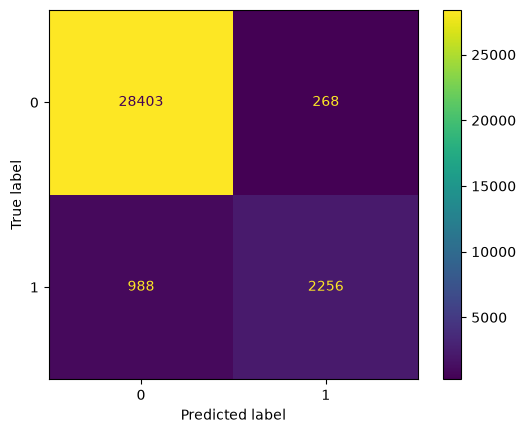

In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.show()

In [22]:
sample = ["You are useless and stupid"]

sample_clean = [clean_text(text) for text in sample]

sample_vector = tfidf.transform(sample_clean)

prediction = svm.predict(sample_vector)

if prediction[0] == 1:
    print("Cyberbullying Detected")
else:
    print("Non-Cyberbullying")

Cyberbullying Detected


In [ ]:
import pickle

pickle.dump(svm, open("../models/svm_model.pkl", "wb"))
pickle.dump(tfidf, open("../models/tfidf.pkl", "wb"))

print("Saved Successfully!")

In [24]:
import os

os.makedirs("../models", exist_ok=True)

In [25]:
import pickle

pickle.dump(svm, open("../models/svm_model.pkl", "wb"))
pickle.dump(tfidf, open("../models/tfidf.pkl", "wb"))

print("Saved Successfully!")

Saved Successfully!


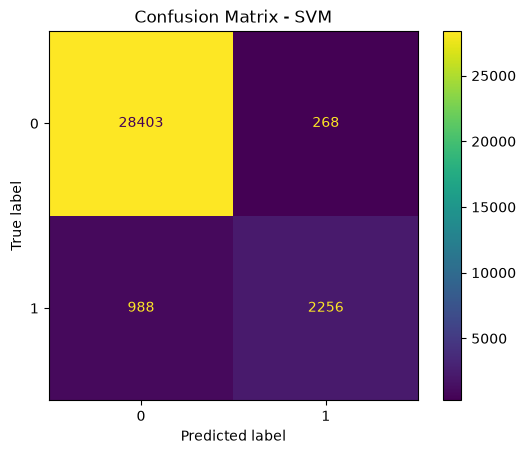

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix - SVM")
plt.show()

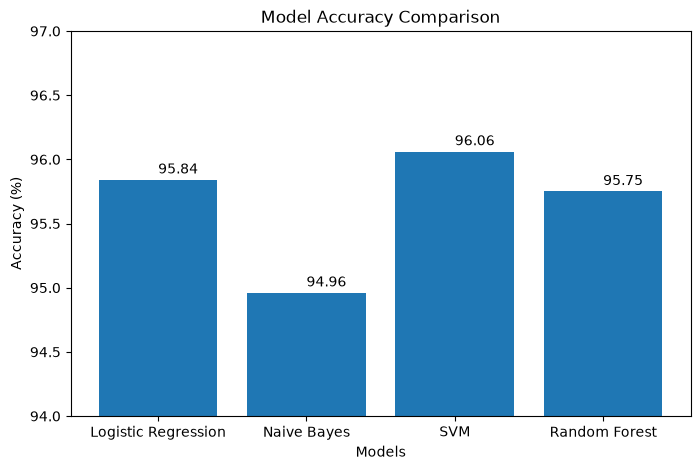

In [28]:
import matplotlib.pyplot as plt

models = [
    "Logistic Regression",
    "Naive Bayes",
    "SVM",
    "Random Forest"
]

accuracies = [
    95.84,
    94.96,
    96.06,
    95.75
]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

plt.ylim(94, 97)

for i, v in enumerate(accuracies):
    plt.text(i, v+0.05, str(v))

plt.show()

In [29]:
def predict_comment(comment):

    cleaned = clean_text(comment)

    vector = tfidf.transform([cleaned])

    prediction = svm.predict(vector)

    if prediction[0] == 1:
        return "Cyberbullying Detected"
    else:
        return "Non-Cyberbullying"

In [30]:
predict_comment("You are a terrible person!")

'Non-Cyberbullying'

In [31]:
comments = [
    "You are stupid",
    "Have a nice day",
    "Nobody likes you",
    "Thank you for your help",
    "I hate you"
]

for comment in comments:
    print(comment, "->", predict_comment(comment))

You are stupid -> Cyberbullying Detected
Have a nice day -> Non-Cyberbullying
Nobody likes you -> Non-Cyberbullying
Thank you for your help -> Non-Cyberbullying
I hate you -> Cyberbullying Detected


In [32]:
results.to_csv("../results/model_results.csv", index=False)

print("Model results saved!")

OSError: Cannot save file into a non-existent directory: '..\results'

In [33]:
import os

os.makedirs("results", exist_ok=True)

In [34]:
results.to_csv("results/model_results.csv", index=False)

print("Model results saved!")

Model results saved!


In [35]:
import os
print(os.getcwd())

e:\Cyberbullying_Detection\notebook


In [37]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred_svm)

with open("../results/classification_report.txt", "w") as f:
    f.write(report)

print("Classification report saved!")

FileNotFoundError: [Errno 2] No such file or directory: '../results/classification_report.txt'

In [38]:
import os

print(os.getcwd())
print(os.path.exists("../results"))


e:\Cyberbullying_Detection\notebook
False


In [39]:
import os

os.makedirs(r"E:\Cyberbullying_Detection\results", exist_ok=True)

print("Results folder created!")


Results folder created!


In [40]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred_svm)

with open(r"E:\Cyberbullying_Detection\results\classification_report.txt", "w") as f:
    f.write(report)

print("Classification report saved!")


Classification report saved!


In [41]:
import pandas as pd

accuracy_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "SVM",
        "Random Forest"
    ],
    "Accuracy": [
        0.958421,
        0.949616,
        0.960645,
        0.957543
    ]
})

accuracy_results.to_csv(
    r"E:\Cyberbullying_Detection\results\model_accuracy.csv",
    index=False
)

print("Accuracy results saved!")


Accuracy results saved!


In [42]:
plt.savefig("../results/accuracy_comparison.png",
            bbox_inches="tight")

print("Accuracy graph saved!")

Accuracy graph saved!


<Figure size 640x480 with 0 Axes>

In [43]:
plt.savefig("../results/confusion_matrix.png",
            bbox_inches="tight")

print("Confusion matrix saved!")

Confusion matrix saved!


<Figure size 640x480 with 0 Axes>

In [44]:
import flask

print(flask.__version__)


3.1.3


C:\Users\Mathi Bala\AppData\Local\Temp\ipykernel_13528\1147077510.py:3: DeprecationWarning: The '__version__' attribute is deprecated and will be removed in Flask 3.2. Use feature detection or 'importlib.metadata.version("flask")' instead.
  print(flask.__version__)
